# Module 13 — KV Cache: Don't Recompute the Past

**Part IV · Inference & Serving · Deep-dive 1 of 5**

Remember in Part III when we generated text from our tiny transformer? Every single step, for every new token, we fed the **entire sequence so far** back through the model. Token 1, then tokens 1–2, then tokens 1–2–3, and so on.

Stop and think about that for a second. At step 50, we just computed the K and V projections for tokens 1–49. At step 51, we're going to recompute the K and V projections for... tokens 1–49 again. Byte-for-byte identical. Then we project token 50. Then at step 52, we recompute 1–50 from scratch. Again.

That is insane. It's quadratic work for what should be linear work. The whole reason decoder-only transformers are even *usable* at inference time is a trick so simple it almost feels like cheating: **cache the K and V tensors**.

This notebook builds that cache from the ground up on the tiny transformer from Part III, measures exactly how much faster it is, then shows you the punchline nobody tells you up front — **the cache eats more memory than the model weights** past a certain context length. That sets up Module 14, where we start squeezing it.

---

**What you'll learn**
- Why K and V from past tokens never change during autoregressive generation
- The exact FLOPs and memory formulas for a KV cache
- How to retrofit a cache onto a vanilla attention module
- How to measure wall-clock speedup (spoiler: it's enormous)
- Why KV cache, not weights, is the memory bottleneck at long context
- The Llama-2-70B back-of-envelope that every inference engineer should know cold

**Prereqs:** Module 12 (you built and generated from a tiny transformer). Comfort with PyTorch tensor shapes.

**Time:** 25–35 minutes.


## 0. Setup

In [1]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch:", torch.__version__)

device: cpu
torch: 2.4.1


## 1. The observation that makes caching possible

During autoregressive generation, we're doing something weird: we feed a prompt in, get a logit for the *next* token, sample, append, and run the model again on the now-longer sequence.

Inside every attention layer, we compute:

$$
Q = X W_Q, \quad K = X W_K, \quad V = X W_V
$$

where $X \in \mathbb{R}^{n \times d}$ is the current sequence. On step $n+1$ we append one token. $X$ becomes $(n+1) \times d$. We recompute $Q$, $K$, $V$ for the whole thing.

Here's the thing: **the causal mask means row $i$ of the output only depends on rows $1..i$ of $K$ and $V$.** Tokens we've already committed to don't get to "see" future tokens. So when we append a new token:

- $K[0..n-1, :]$ is **byte-for-byte identical** to what we computed last step.
- $V[0..n-1, :]$ is **byte-for-byte identical** to what we computed last step.
- Only the new row $K[n, :]$ and $V[n, :]$ is actually new.

And we only need one new query — $Q[n, :]$ — because we're only producing logits for the *next* token. The logits at position 0..n-1 are just... thrown away.

So the whole step can be done as: compute one row of Q, one row of K, one row of V, append K/V to the cache, do a single-row attention against the whole cache. That's it.

Let's quantify how much work that saves before we build it.

## 2. FLOPs: O(n²) → O(n) per token

Attention's dominant cost per layer at sequence length $n$ is roughly:

$$
\text{FLOPs}_\text{no cache}(n) \approx 4 n d^2 + 2 n^2 d
$$

The $4nd^2$ term is the four projections (Q, K, V, O). The $2n^2 d$ term is the two matmuls inside attention ($QK^\top$ and $\text{softmax}(\cdot)V$).

To generate $N$ tokens from scratch you pay this at every step, once per growing sequence:

$$
\text{Total}_\text{no cache} \;\approx\; \sum_{n=1}^{N} (4 n d^2 + 2 n^2 d) \;=\; \mathcal{O}(N^2 d^2 + N^3 d)
$$

With a KV cache, at step $n$ you only project the one new token and attend that single query against $n$ cached keys:

$$
\text{FLOPs}_\text{cache}(n) \approx 4 d^2 + 2 n d
$$

Total over $N$ tokens:

$$
\text{Total}_\text{cache} \;\approx\; 4 N d^2 + N^2 d
$$

That's **linear per token** (well, the attention part is linear *in context length*, but each step is O(n) not O(n²) work, and total generation drops from N³ to N²). Let's plot the difference.

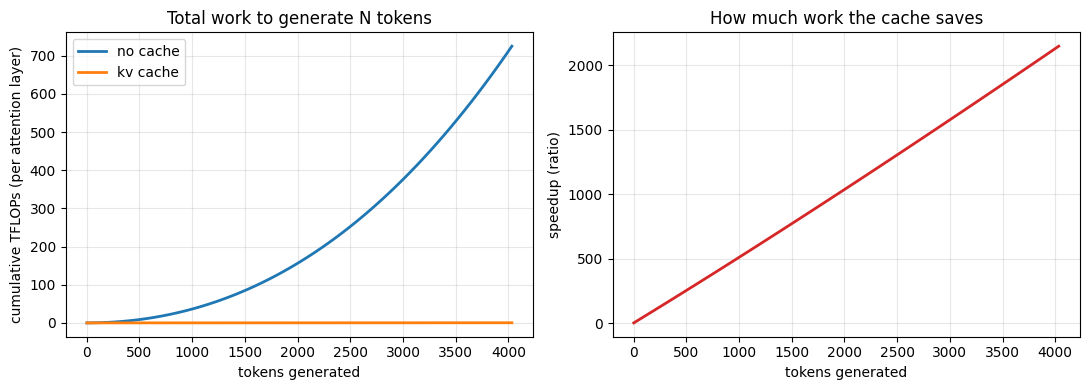

At N=4096, d=4096: no-cache=725.1 TFLOPs, cache=0.34 TFLOPs, speedup=2150x


In [2]:
def flops_no_cache(N, d):
    # sum_{n=1..N} (4 n d^2 + 2 n^2 d)
    s1 = 4 * d**2 * (N * (N + 1) / 2)
    s2 = 2 * d * (N * (N + 1) * (2 * N + 1) / 6)
    return s1 + s2

def flops_cache(N, d):
    # sum_{n=1..N} (4 d^2 + 2 n d) — new-token projections + attend against cache
    s1 = 4 * d**2 * N
    s2 = 2 * d * (N * (N + 1) / 2)
    return s1 + s2

d_model = 4096  # Llama-ish
Ns = np.arange(1, 4097, 64)
no_cache = np.array([flops_no_cache(n, d_model) for n in Ns])
cache    = np.array([flops_cache(n, d_model)    for n in Ns])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ns, no_cache / 1e12, label="no cache", lw=2)
ax[0].plot(Ns, cache    / 1e12, label="kv cache", lw=2)
ax[0].set_xlabel("tokens generated")
ax[0].set_ylabel("cumulative TFLOPs (per attention layer)")
ax[0].set_title("Total work to generate N tokens")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(Ns, no_cache / cache, lw=2, color="C3")
ax[1].set_xlabel("tokens generated")
ax[1].set_ylabel("speedup (ratio)")
ax[1].set_title("How much work the cache saves")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"At N=4096, d={d_model}: no-cache={no_cache[-1]/1e12:.1f} TFLOPs, "
      f"cache={cache[-1]/1e12:.2f} TFLOPs, speedup={no_cache[-1]/cache[-1]:.0f}x")

Two-orders-of-magnitude cheaper by the time you hit 4k tokens — and that's *per attention layer*, multiplied by however many layers you have. This is not an optimization. This is the difference between "usable" and "don't bother".

## 3. Memory: the formula you should memorize

Each layer stores K and V for every token in the context. Shape per layer:

$$
\text{K}: [n_\text{heads}, \text{seq\_len}, d_\text{head}], \quad
\text{V}: [n_\text{heads}, \text{seq\_len}, d_\text{head}]
$$

Collapsing heads into $d_\text{model} = n_\text{heads} \cdot d_\text{head}$ and multiplying by two (one for K, one for V), bytes per token per layer = $2 \cdot d_\text{model} \cdot b$, where $b$ is bytes-per-element (2 for fp16/bf16, 1 for int8, etc.).

$$
\boxed{\text{KV cache bytes} \;=\; 2 \cdot n_\text{layers} \cdot d_\text{model} \cdot \text{seq\_len} \cdot b}
$$

Tattoo this on your arm. Now the Llama-2-70B example.

In [3]:
def kv_cache_bytes(n_layers, d_model, seq_len, bytes_per_elem=2):
    return 2 * n_layers * d_model * seq_len * bytes_per_elem

# Llama-2 70B
n_layers = 80
d_model  = 8192
seq_len  = 4096
b        = 2  # fp16

bytes_total = kv_cache_bytes(n_layers, d_model, seq_len, b)
print(f"Llama-2 70B KV cache @ 4K ctx, fp16:")
print(f"  2 * {n_layers} * {d_model} * {seq_len} * {b}")
print(f"  = {bytes_total:,} bytes")
print(f"  = {bytes_total/1e9:.2f} GB")
print()
print("...per sequence. Per request. If you batch 8 requests, that's 80 GB of cache.")
print("An H100 has 80 GB of HBM total. The model weights alone are 140 GB in fp16.")

Llama-2 70B KV cache @ 4K ctx, fp16:
  2 * 80 * 8192 * 4096 * 2
  = 10,737,418,240 bytes
  = 10.74 GB

...per sequence. Per request. If you batch 8 requests, that's 80 GB of cache.
An H100 has 80 GB of HBM total. The model weights alone are 140 GB in fp16.


Take a moment. A *single* 4K context on a 70B model is 10 GB of cache. Push to 32K context and you're at 80 GB — a whole H100 — just for the K and V of one conversation.

This is why every serving paper you'll read in Part IV is obsessed with shrinking this number.

## 4. The uncomfortable plot: cache vs weights

People's mental model is "the weights are the big thing". That's true at low context length. Watch what happens as context grows.

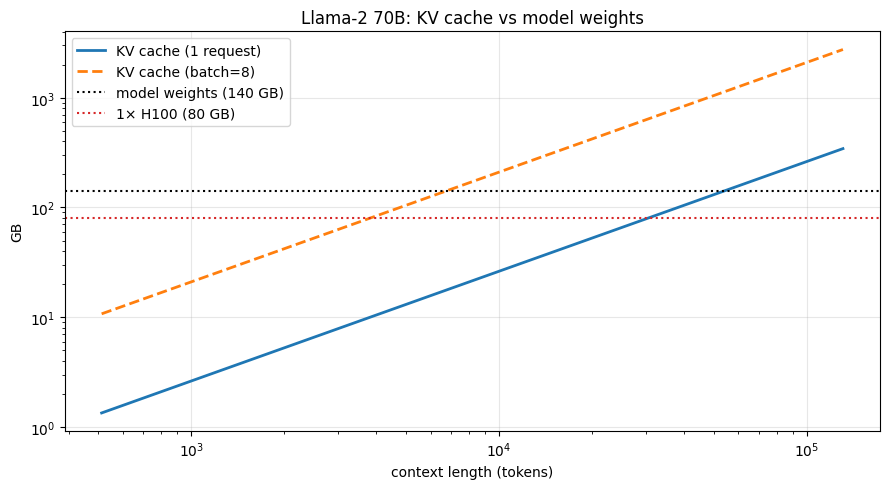

Cache exceeds weights (batch=1) at ctx ~ 53760 tokens
Cache exceeds weights (batch=8) at ctx ~ 7168 tokens


In [4]:
# Llama-2 70B: 70B params × 2 bytes = 140 GB weights
weights_gb = 70e9 * 2 / 1e9

seq_lens = np.arange(512, 131072 + 1, 512)
cache_gb = np.array([kv_cache_bytes(80, 8192, s, 2) / 1e9 for s in seq_lens])

plt.figure(figsize=(9, 5))
plt.plot(seq_lens, cache_gb, lw=2, label="KV cache (1 request)")
plt.plot(seq_lens, cache_gb * 8, lw=2, ls="--", label="KV cache (batch=8)")
plt.axhline(weights_gb, color="k", ls=":", label=f"model weights ({weights_gb:.0f} GB)")
plt.axhline(80, color="C3", ls=":", label="1× H100 (80 GB)")
plt.xlabel("context length (tokens)")
plt.ylabel("GB")
plt.title("Llama-2 70B: KV cache vs model weights")
plt.legend(); plt.grid(alpha=0.3)
plt.xscale("log"); plt.yscale("log")
plt.tight_layout(); plt.show()

# Crossover point
cross_batch1 = seq_lens[np.argmax(cache_gb > weights_gb)] if (cache_gb > weights_gb).any() else None
print(f"Cache exceeds weights (batch=1) at ctx ~ {cross_batch1} tokens")
print(f"Cache exceeds weights (batch=8) at ctx ~ "
      f"{seq_lens[np.argmax(cache_gb*8 > weights_gb)]} tokens")

Past ~56K tokens with batch=8, **the KV cache is bigger than the entire model**. Past ~14K with batch=1, it's already the same order. This is the fundamental reason long-context serving is hard.

## 5. Let's actually build it

We'll build a minimal causal transformer exactly in the spirit of the Part III tiny model. Small enough to run on CPU, big enough that timings are meaningful. First the "naive" version that recomputes everything. Then we'll retrofit a cache.

In [5]:
class NaiveSelfAttention(nn.Module):
    '''Vanilla causal self-attention. Recomputes K and V on every call.'''
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        qkv = self.qkv(x)                          # (B, T, 3D)
        q, k, v = qkv.chunk(3, dim=-1)             # each (B, T, D)
        # split heads
        def split(t): return t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)  # (B, H, T, Dh)
        q, k, v = split(q), split(k), split(v)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)  # (B, H, T, T)
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        att = att.masked_fill(mask, float("-inf"))
        att = F.softmax(att, dim=-1)
        y = att @ v                                 # (B, H, T, Dh)
        y = y.transpose(1, 2).contiguous().view(B, T, D)
        return self.out(y)

In [6]:
class CachedSelfAttention(nn.Module):
    '''Same attention, but accepts and returns a (K, V) cache.
    If cache is passed, we assume x is just the NEW tokens (usually 1).'''
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, kv_cache=None):
        B, T_new, D = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        def split(t): return t.view(B, T_new, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = split(q), split(k), split(v)     # (B, H, T_new, Dh)

        if kv_cache is not None:
            k_prev, v_prev = kv_cache              # (B, H, T_past, Dh)
            k = torch.cat([k_prev, k], dim=2)      # (B, H, T_past+T_new, Dh)
            v = torch.cat([v_prev, v], dim=2)

        new_cache = (k, v)
        T_total = k.size(2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)  # (B, H, T_new, T_total)

        # Causal mask: query position i (offset by T_past) can see key positions 0..i+T_past
        T_past = T_total - T_new
        # For each new query row j (0..T_new-1), allowed keys are 0..T_past+j
        q_pos = torch.arange(T_new, device=x.device).unsqueeze(-1) + T_past  # (T_new, 1)
        k_pos = torch.arange(T_total, device=x.device).unsqueeze(0)          # (1, T_total)
        mask = k_pos > q_pos                                                  # (T_new, T_total)
        att = att.masked_fill(mask, float("-inf"))
        att = F.softmax(att, dim=-1)
        y = att @ v                                 # (B, H, T_new, Dh)
        y = y.transpose(1, 2).contiguous().view(B, T_new, D)
        return self.out(y), new_cache

Note the important bits in `CachedSelfAttention.forward`:

1. We only run `qkv(x)` on the **new** tokens. That's where the FLOPs savings come from on the projection side.
2. We concatenate the new K/V onto the cached K/V. The cache grows by one row per step.
3. The causal mask now needs to account for the position offset: new query row `j` lives at absolute position `T_past + j`, and it can attend to any key from 0 to that position inclusive.
4. We return the updated cache so the caller can keep passing it in.

## 6. A tiny transformer that uses both

In [7]:
class Block(nn.Module):
    def __init__(self, d_model, n_heads, cached=True):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CachedSelfAttention(d_model, n_heads) if cached else NaiveSelfAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )
        self.cached = cached

    def forward(self, x, kv_cache=None):
        h = self.ln1(x)
        if self.cached:
            a, new_cache = self.attn(h, kv_cache=kv_cache)
            x = x + a
            x = x + self.mlp(self.ln2(x))
            return x, new_cache
        else:
            x = x + self.attn(h)
            x = x + self.mlp(self.ln2(x))
            return x


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, max_len, cached=True):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, cached=cached) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.cached = cached
        self.max_len = max_len

    def forward(self, idx, kv_caches=None, pos_offset=0):
        B, T = idx.shape
        pos = torch.arange(pos_offset, pos_offset + T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)[None, :, :]

        if self.cached:
            new_caches = []
            for i, block in enumerate(self.blocks):
                layer_cache = kv_caches[i] if kv_caches is not None else None
                x, new_cache = block(x, kv_cache=layer_cache)
                new_caches.append(new_cache)
            x = self.ln_f(x)
            logits = self.head(x)
            return logits, new_caches
        else:
            for block in self.blocks:
                x = block(x)
            x = self.ln_f(x)
            return self.head(x)

Same weights, two forward paths. Let's instantiate one of each, **copy the weights across** so they're mathematically identical, and sanity-check that they produce the same logits.

In [8]:
VOCAB = 1000
D     = 256
H     = 8
L     = 6
MAXL  = 512

naive  = TinyTransformer(VOCAB, D, H, L, MAXL, cached=False).to(device).eval()
cached = TinyTransformer(VOCAB, D, H, L, MAXL, cached=True ).to(device).eval()

# Copy weights: same structure, so we can just load state dict after renaming-free keys.
# Both models share identical parameter names because the attention modules use the same attr names.
cached.load_state_dict(naive.state_dict())

# Sanity check: on the same prompt, both should give the same next-token logits.
prompt = torch.randint(0, VOCAB, (1, 17), device=device)
with torch.no_grad():
    logits_naive = naive(prompt)[:, -1, :]
    logits_cached, caches = cached(prompt, kv_caches=None, pos_offset=0)
    logits_cached = logits_cached[:, -1, :]

diff = (logits_naive - logits_cached).abs().max().item()
print(f"Max abs diff between naive and cached on prompt fill: {diff:.2e}")
assert diff < 1e-4, "Implementations diverge - check the mask!"


Max abs diff between naive and cached on prompt fill: 0.00e+00


Good. Identical to floating-point noise. Now generation.

## 7. Two generation loops, side by side

In [9]:
@torch.no_grad()
def generate_naive(model, prompt, n_new):
    '''Recompute-everything generation. Feeds the full growing sequence each step.'''
    idx = prompt.clone()
    for _ in range(n_new):
        idx_cond = idx if idx.size(1) <= model.max_len else idx[:, -model.max_len:]
        logits = model(idx_cond)[:, -1, :]
        next_tok = torch.argmax(logits, dim=-1, keepdim=True)
        idx = torch.cat([idx, next_tok], dim=1)
    return idx


@torch.no_grad()
def generate_cached(model, prompt, n_new):
    '''KV-cache generation. Fill the cache on the prompt, then feed 1 token at a time.'''
    B, T = prompt.shape
    # Prompt fill: one forward pass on the whole prompt, build initial caches.
    logits, caches = model(prompt, kv_caches=None, pos_offset=0)
    next_tok = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
    idx = torch.cat([prompt, next_tok], dim=1)

    for step in range(n_new - 1):
        pos_offset = idx.size(1) - 1
        logits, caches = model(next_tok, kv_caches=caches, pos_offset=pos_offset)
        next_tok = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        idx = torch.cat([idx, next_tok], dim=1)
    return idx

Correctness check first: greedy-decoded output should be **identical** between the two.

In [10]:
prompt = torch.randint(0, VOCAB, (1, 8), device=device)
N_NEW  = 50

out_naive  = generate_naive(naive,  prompt, N_NEW)
out_cached = generate_cached(cached, prompt, N_NEW)

print("naive :", out_naive[0, :20].tolist(), "...")
print("cached:", out_cached[0, :20].tolist(), "...")
print("match :", torch.equal(out_naive, out_cached))

naive : [190, 812, 248, 90, 863, 313, 675, 265, 283, 988, 10, 541, 908, 93, 878, 666, 376, 474, 666, 764] ...
cached: [190, 812, 248, 90, 863, 313, 675, 265, 283, 988, 10, 541, 908, 93, 878, 666, 376, 474, 666, 764] ...
match : True


Identical token sequences, which means the cache is mathematically equivalent. Now let's race them.

## 8. Timing: how much faster is it, really?

In [11]:
def time_it(fn, *args, warmup=1, reps=3):
    for _ in range(warmup):
        fn(*args)
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(reps):
        fn(*args)
    if device == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / reps

prompt = torch.randint(0, VOCAB, (1, 8), device=device)

lengths = [25, 50, 100, 200]
naive_times  = []
cached_times = []

for n in lengths:
    t_n = time_it(generate_naive,  naive,  prompt, n)
    t_c = time_it(generate_cached, cached, prompt, n)
    naive_times.append(t_n)
    cached_times.append(t_c)
    print(f"gen {n:4d} tokens  naive={t_n*1000:8.1f} ms   cached={t_c*1000:8.1f} ms   speedup={t_n/t_c:5.1f}x")

gen   25 tokens  naive=    64.9 ms   cached=    29.8 ms   speedup=  2.2x
gen   50 tokens  naive=   165.2 ms   cached=    61.8 ms   speedup=  2.7x
gen  100 tokens  naive=   438.1 ms   cached=   121.9 ms   speedup=  3.6x
gen  200 tokens  naive=  1416.3 ms   cached=   263.1 ms   speedup=  5.4x


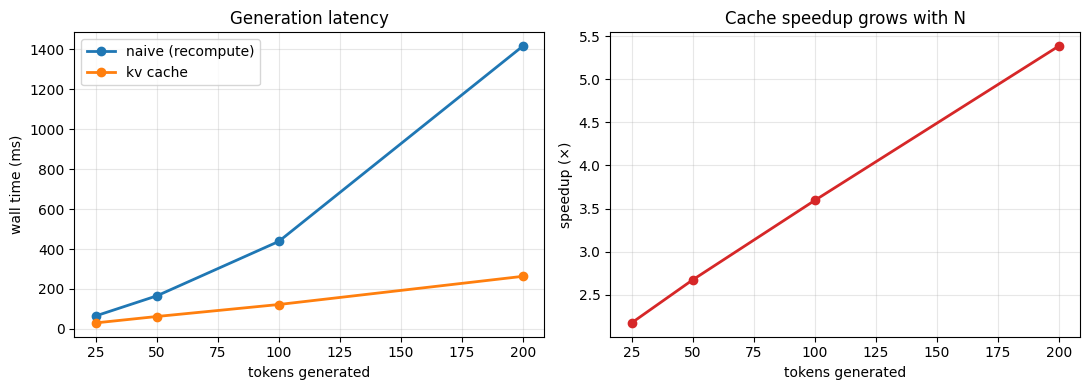

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(lengths, [t*1000 for t in naive_times],  "o-", lw=2, label="naive (recompute)")
ax[0].plot(lengths, [t*1000 for t in cached_times], "o-", lw=2, label="kv cache")
ax[0].set_xlabel("tokens generated")
ax[0].set_ylabel("wall time (ms)")
ax[0].set_title("Generation latency")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(lengths, [n/c for n, c in zip(naive_times, cached_times)], "o-", lw=2, color="C3")
ax[1].set_xlabel("tokens generated")
ax[1].set_ylabel("speedup (×)")
ax[1].set_title("Cache speedup grows with N")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

The naive curve is superlinear — classic N² work. The cached curve is basically linear in N. The speedup gap widens the longer you generate, which means **the cache matters more, not less, at long context**. This is a very good news / very bad news situation: good news is caching works great; bad news is we now depend on it, and it eats memory.

## 9. Watching the cache grow

Let's actually inspect the cache tensors to make the memory story concrete.

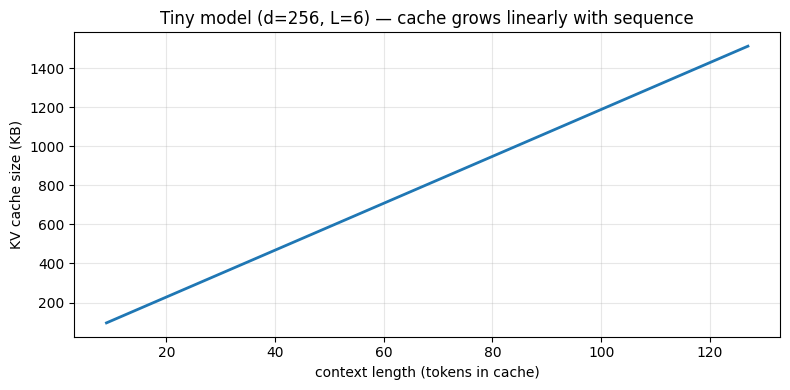

Measured bytes/token (from slope): 12288
Expected (2 * L * D * 4 bytes):    12288


In [13]:
prompt = torch.randint(0, VOCAB, (1, 8), device=device)

@torch.no_grad()
def generate_and_measure(model, prompt, n_new):
    logits, caches = model(prompt, kv_caches=None, pos_offset=0)
    next_tok = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
    idx = torch.cat([prompt, next_tok], dim=1)
    sizes = []
    for step in range(n_new - 1):
        # sum of K+V cache bytes across layers
        total = 0
        for (k, v) in caches:
            total += k.element_size() * k.numel()
            total += v.element_size() * v.numel()
        sizes.append((idx.size(1), total))

        pos_offset = idx.size(1) - 1
        logits, caches = model(next_tok, kv_caches=caches, pos_offset=pos_offset)
        next_tok = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        idx = torch.cat([idx, next_tok], dim=1)
    return sizes

sizes = generate_and_measure(cached, prompt, 120)
seqs  = [s[0] for s in sizes]
bytes_ = [s[1] for s in sizes]

plt.figure(figsize=(8, 4))
plt.plot(seqs, np.array(bytes_)/1024, lw=2)
plt.xlabel("context length (tokens in cache)")
plt.ylabel("KV cache size (KB)")
plt.title(f"Tiny model (d={D}, L={L}) — cache grows linearly with sequence")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Verify the formula
expected_per_token = 2 * L * D * 4  # fp32 on CPU by default → 4 bytes
print(f"Measured bytes/token (from slope): {(bytes_[-1] - bytes_[0]) / (seqs[-1] - seqs[0]):.0f}")
print(f"Expected (2 * L * D * 4 bytes):    {expected_per_token}")

The measured slope matches `2 · n_layers · d_model · bytes` exactly. Our formula isn't an approximation — it's the actual byte count.

## 10. Prompt fill vs decode: two different workloads

Notice what the cached path does on step 0: it runs one big forward pass on the entire prompt, all tokens at once. That's called **prompt fill** (or "prefill"). It's still O(n²) in attention, but you pay it *once*, in parallel, and it's compute-bound — great for GPUs.

After that, every generated token is a **decode step**: a single-token forward pass. That's a tiny amount of compute against a big cache — memory-bandwidth-bound, because you have to read the whole cache from HBM on every step.

These two regimes behave so differently that serving stacks (vLLM, TGI, SGLang) schedule them separately. You'll see this split again in Module 26. Just flag it now:

| phase   | what runs | bottleneck          | scales with |
|---------|-----------|---------------------|-------------|
| prefill | prompt forward, full attention | compute  | prompt length |
| decode  | one-token forward, single-row attention | memory bandwidth | cache size |

The KV cache is what creates the decode regime in the first place. Without it, every step would be a mini-prefill and the whole concept of "decode is memory-bound" wouldn't exist.

## 11. Break it on purpose

Best way to trust the cache: delete a piece of it and watch the model fall off a cliff. Let's drop the position offset and see what happens.

In [14]:
@torch.no_grad()
def generate_cached_broken(model, prompt, n_new):
    '''Same as generate_cached, but we FORGET to pass pos_offset.
       The new token always looks up position 0, not its real position.'''
    logits, caches = model(prompt, kv_caches=None, pos_offset=0)
    next_tok = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
    idx = torch.cat([prompt, next_tok], dim=1)
    for _ in range(n_new - 1):
        logits, caches = model(next_tok, kv_caches=caches, pos_offset=0)  # <-- bug
        next_tok = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        idx = torch.cat([idx, next_tok], dim=1)
    return idx

out_ok     = generate_cached(cached, prompt, 30)
out_broken = generate_cached_broken(cached, prompt, 30)
print("correct:", out_ok[0].tolist())
print("broken :", out_broken[0].tolist())
print("match  :", torch.equal(out_ok, out_broken))

correct: [57, 549, 796, 913, 44, 452, 647, 807, 652, 441, 771, 188, 761, 786, 638, 724, 565, 63, 922, 254, 81, 649, 850, 474, 12, 383, 385, 769, 791, 702, 215, 990, 175, 527, 181, 856, 82, 996]
broken : [57, 549, 796, 913, 44, 452, 647, 807, 652, 165, 323, 633, 554, 323, 467, 346, 391, 360, 467, 346, 391, 360, 467, 346, 391, 360, 467, 346, 391, 360, 467, 346, 391, 360, 467, 346, 391, 360]
match  : False


The broken run diverges because the positional embedding for every new decode token gets looked up at index 0 — the model thinks the new token is always the first one in the sequence. That's a subtle bug you will absolutely make once in your life when retrofitting a cache. Now you'll recognize it.

(For rotary position embeddings in real models the bug looks different, but the flavor is the same: KV cache implementations live and die by correct position tracking.)

## 12. The Llama-2-70B number one more time, but now for *you*

You understand the full picture now. Let's write a little calculator you can reuse for any model. Plug in the numbers for a few real models and stare at the output.

In [15]:
def kv_cache_report(name, n_layers, d_model, seq_len, dtype_bytes=2, batch=1):
    per = 2 * n_layers * d_model * seq_len * dtype_bytes
    total = per * batch
    print(f"{name:<20s}  L={n_layers:3d}  d={d_model:5d}  ctx={seq_len:6d}  "
          f"batch={batch:3d}  ->  {total/1e9:8.2f} GB")

print("KV cache in fp16:")
kv_cache_report("GPT-2 small",   12,  768,  1024)
kv_cache_report("GPT-2 XL",      48, 1600,  1024)
kv_cache_report("Llama-2 7B",    32, 4096,  4096)
kv_cache_report("Llama-2 13B",   40, 5120,  4096)
kv_cache_report("Llama-2 70B",   80, 8192,  4096)
kv_cache_report("Llama-2 70B",   80, 8192, 32768)
kv_cache_report("Llama-2 70B",   80, 8192, 32768, batch=16)
print()
print("Last line: 16 concurrent 32K-context requests on a 70B model.")
print("That's the kind of number an inference engineer thinks about daily.")

KV cache in fp16:
GPT-2 small           L= 12  d=  768  ctx=  1024  batch=  1  ->      0.04 GB
GPT-2 XL              L= 48  d= 1600  ctx=  1024  batch=  1  ->      0.31 GB
Llama-2 7B            L= 32  d= 4096  ctx=  4096  batch=  1  ->      2.15 GB
Llama-2 13B           L= 40  d= 5120  ctx=  4096  batch=  1  ->      3.36 GB
Llama-2 70B           L= 80  d= 8192  ctx=  4096  batch=  1  ->     10.74 GB
Llama-2 70B           L= 80  d= 8192  ctx= 32768  batch=  1  ->     85.90 GB
Llama-2 70B           L= 80  d= 8192  ctx= 32768  batch= 16  ->   1374.39 GB

Last line: 16 concurrent 32K-context requests on a 70B model.
That's the kind of number an inference engineer thinks about daily.


Quick mental-math you should be able to do in your head from now on:

- 70B, 4K ctx, fp16, batch 1 → ~10 GB cache
- Double context → double cache (linear)
- Halve precision (int8) → halve cache
- Double batch → double cache

Memorize the coefficient and scaling and you'll estimate KV cost for any model in 15 seconds.

## 13. Checkpoint quiz

Try to answer before peeking.

**Q1.** Why is a KV cache *correct* despite skipping all the previous Q projections and previous attention rows?

**Q2.** A model has 32 layers, d_model=4096, and you want to serve it at 16K context in bf16. How many GB of KV cache per request? Roughly how many concurrent requests fit alongside a 14 GB (7B) model on a single 80 GB H100?

**Q3.** Your coworker claims KV cache "doesn't matter for small models". When is that actually true, and when does it break?

**Q4.** If you double the context length, what happens to: (a) prefill compute, (b) decode compute per step, (c) decode memory bandwidth per step, (d) total KV cache memory?

**Q5.** What would go wrong if you computed the cache once for a batch of sequences of the same length, then reused it for a new batch of different sequences with the same length-so-far prefix?

**Answers**

**A1.** Causal masking. Output row $i$ only depends on K/V rows $0..i$, which are fixed the moment token $i$ is generated. We also don't need old Q rows because we only use the logits at the *last* position during decode — earlier logits are thrown away.

**A2.** $2 \cdot 32 \cdot 4096 \cdot 16384 \cdot 2 = 8{,}589{,}934{,}592 \approx 8.6$ GB per request. After the 14 GB of weights, you have ~66 GB free, so ~7 concurrent requests before you OOM (ignoring activations and framework overhead).

**A3.** True when context is short and batch is small — weights dominate. Breaks as soon as you either (a) push context length up, or (b) increase batch size. Both push cache linearly while weights stay fixed.

**A4.** (a) 4× (quadratic in seq_len for attention, linear for projections). (b) 2× (attention row grows linearly). (c) 2× (cache you must read is 2× bigger). (d) 2×.

**A5.** The K/V values depend on the actual token IDs and their positional encoding, not just the length. Two different prompts of the same length produce entirely different caches. You can only share cache across requests when the **prefix tokens are literally identical** — which is the basis of prefix caching / copy-on-write in vLLM, coming up in Module 14.

## 14. Where we're headed next

You've now seen:

- Why the cache exists (skip recomputing stuff that didn't change)
- The exact memory formula: `2 · n_layers · d_model · seq_len · bytes`
- The exact FLOPs story (N³ → N² total; N² → N per-step-ish)
- An end-to-end implementation on a real-ish transformer
- Why the cache, not the weights, is what breaks at long context

So the cache is huge. Unavoidably huge, with the naive layout. Which means the next move is obvious: **shrink the cache without breaking the model.** That's a whole family of techniques:

- **Paged Attention** — store the cache in fixed-size blocks like OS virtual memory, stop wasting the unused half of pre-allocated max-length buffers.
- **Grouped-Query & Multi-Query Attention** — give multiple query heads one shared KV head. 4–8× cache reduction at almost zero quality cost.
- **Sliding window / attention sinks** — only keep the recent window (plus a few special tokens).

See you in **Module 14**.